In [91]:
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
import pickle
import matplotlib.pyplot as plt

In [2]:
torch.cuda.is_available()

True

In [3]:
# Use GPU if it is avaialable
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [75]:
df = pd.read_csv("Climate_data.csv")

data = df.drop("Date Time" , axis=1)
column_label = data.columns.tolist()
data = torch.tensor(data.values , dtype=torch.float32)

mean = data.mean(dim=0)
std = data.std(dim=0)

data = (data - mean)/std

In [56]:
data_X = []
data_y = []

for i in range(len(data) - (72*6)-1):
    data_X.append(data[i:i+(72*6)])
    data_y.append(data[i+(72*6)])
data_X = torch.stack(data_X)
data_y = torch.stack(data_y)

In [57]:
dataset = TensorDataset(data_X , data_y)
loader = DataLoader(dataset , batch_size=5000 , shuffle=True)

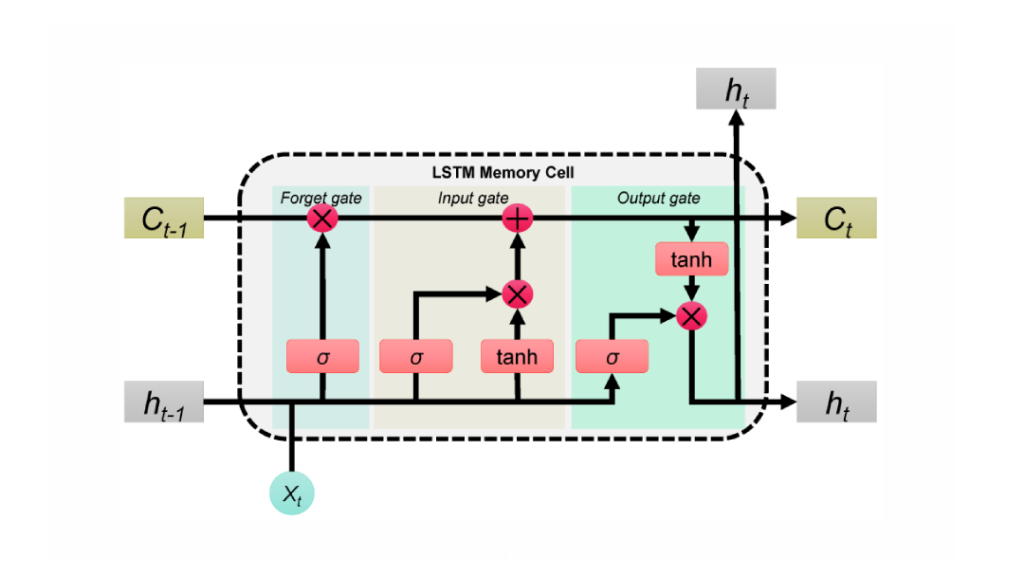

In [ ]:
class LSTM_Layer(nn.Module):
    def __init__(self , input_dim , hidden_dim):
        super().__init__()
        

        # Forget Gate - How much of the current long term memory should be kept
        self.fb_input = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.fb_memory = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Input Gate - What is the new long term memory and how much of it do we have to remember
        self.ig_input_potmem = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.ig_memory_potmem = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)
        self.ig_input_perc = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.ig_memory_perc = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

        # Output Gate - what should be the new short term memory seeing the current long term memory and current inputs
        self.og_input = nn.Linear(in_features=input_dim , out_features=hidden_dim)
        self.og_memory = nn.Linear(in_features=hidden_dim , out_features=hidden_dim)

    def forward(self , x , h , c):
        # h = hidden state (short term memory)
        # c = cell state (long term memory)


        # forget gate
        fg = self.fb_input(x) + self.fb_memory(h)
        fg = torch.sigmoid(fg)
        c = c*fg

        # Input Gate
        ig_potmem = self.ig_input_potmem(x) + self.ig_memory_potmem(h)
        ig_potmem = torch.tanh(ig_potmem)
        ig_perc = self.ig_input_perc(x) + self.ig_memory_perc(h)
        ig_perc = torch.sigmoid(ig_perc)
        ig = ig_potmem * ig_perc
        c = c + ig

        # Output Gate
        og = self.og_input(x) + self.og_memory(h)
        og = torch.sigmoid(og)
        h = torch.tanh(c) * og
    
        return h,c
    


class LSTM(nn.Module):
    def __init__(self , hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.Layer1 = LSTM_Layer(14 , hidden_dim)
        # self.Layer2 = LSTM_Layer(hidden_dim , hidden_dim)    # for if you need two layers
        self.final = nn.Linear(in_features=hidden_dim , out_features=14)

    def forward(self , x):
        h1 = torch.zeros(x.shape[0],self.hidden_dim).to(device)
        c1 = torch.zeros(x.shape[0],self.hidden_dim).to(device)
        # h2 = torch.zeros(x.shape[0],self.hidden_dim).to(device)   # for if you need two layers
        # c2 = torch.zeros(x.shape[0],self.hidden_dim).to(device)   # for if you need two layers
        x = x.to(device)

        for i in range(x.shape[1]):
            h1,c1 = self.Layer1(x[:,i,:] , h1 , c1)
            # h2,c2 = self.Layer2(h1 , h2 , c2)     # for if you need two layers
        y_pred = self.final(h1)     
        # y_pred = self.final(h2)   # for if you need two layers also comment out the upper line
        return y_pred

In [61]:
torch.manual_seed(12)
Model = LSTM(32).to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(Model.parameters() , lr=1e-3 , weight_decay=1e-5)

losses = []
epochs = 10

for epoch in range(epochs):
    running_loss = 0
    batch = 1
    for X,y in loader:
        y_pred = Model(X)
        loss = loss_fn(y_pred,y.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss = running_loss + loss.item()
        print(f"Epoch : {epoch}\tBatch : {batch}/{len(loader)}\tLoss : {loss.item()}")
        batch = batch+1
    losses.append(running_loss/len(loader))
    print(f"----------Epoch : {epoch}\tLoss in Entire Epoch : {running_loss/len(loader)}----------\n")

Epoch : 0	Batch : 1/85	Loss : 0.9238401055335999
Epoch : 0	Batch : 2/85	Loss : 0.9242130517959595
Epoch : 0	Batch : 3/85	Loss : 1.5358561277389526
Epoch : 0	Batch : 4/85	Loss : 0.8836799263954163
Epoch : 0	Batch : 5/85	Loss : 0.8779081702232361
Epoch : 0	Batch : 6/85	Loss : 0.8620098829269409
Epoch : 0	Batch : 7/85	Loss : 0.8430827260017395
Epoch : 0	Batch : 8/85	Loss : 1.4835513830184937
Epoch : 0	Batch : 9/85	Loss : 1.451808214187622
Epoch : 0	Batch : 10/85	Loss : 0.8106045126914978
Epoch : 0	Batch : 11/85	Loss : 0.7985720634460449
Epoch : 0	Batch : 12/85	Loss : 0.7865257263183594
Epoch : 0	Batch : 13/85	Loss : 1.6879312992095947
Epoch : 0	Batch : 14/85	Loss : 0.7583901286125183
Epoch : 0	Batch : 15/85	Loss : 0.7445549964904785
Epoch : 0	Batch : 16/85	Loss : 0.7239552140235901
Epoch : 0	Batch : 17/85	Loss : 0.706804633140564
Epoch : 0	Batch : 18/85	Loss : 1.3525259494781494
Epoch : 0	Batch : 19/85	Loss : 0.712439239025116
Epoch : 0	Batch : 20/85	Loss : 0.6913366317749023
Epoch : 0	Ba

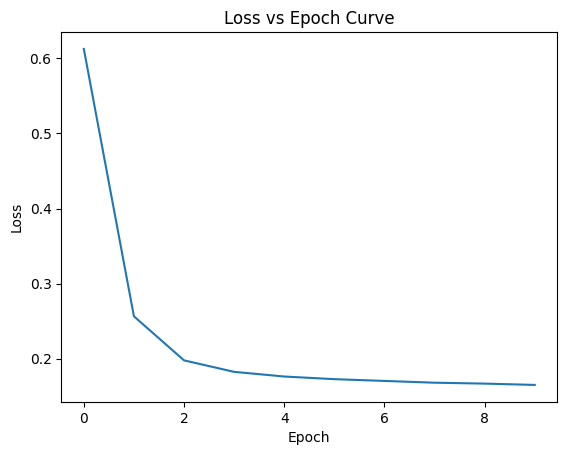

In [93]:
plt.plot(losses)
plt.title("Loss vs Epoch Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Saving model weights
weights = Model.state_dict()
with open("LSTM_model_weights.pkl","wb") as F:
    pickle.dump(weights , F)

In [ ]:
# Seeing all the values predicted and actual values to see how close they are
with torch.no_grad():
    X,y = next(iter(loader))
    X = X[0].unsqueeze(dim=0)
    y = y[0]
    y_pred = Model(X.to(device))
    df = pd.DataFrame([(y*std + mean).numpy(),(y_pred[0].cpu()*std + mean).numpy()])
    df.columns = column_label

In [88]:
df

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,995.700012,10.370000,283.880005,7.420000,81.900002,12.600000,10.320000,2.280000,6.470000,10.370000,1218.579956,1.670000,2.560000,188.100006
1,996.087769,10.212178,283.691803,7.424864,83.414337,12.381203,10.334983,2.102737,6.513494,10.353713,1220.256714,1.558958,2.542209,184.285492
